# 05 - Backtesting para la estrategia DOGE/USDT

## Objetivo del notebook

Este notebook implementa un sistema de backtesting para evaluar si las predicciones generadas por el modelo XGBoost pueden transformarse en una estrategia de trading mínimamente viable.

A diferencia del notebook de baseline, el objetivo ya no es medir únicamente métricas de clasificación, sino analizar el comportamiento financiero de una estrategia completa bajo condiciones más cercanas a un entorno real.

El notebook incorpora:

- Separación temporal estricta
- Generación de probabilidades de trading
- Conversión de predicciones en señales operativas
- Gestión de posiciones
- Stop loss y take profit dinámicos
- Control básico de exposición
- Comparación frente a Buy & Hold
- Métricas financieras
- Visualización de equity y drawdown

La finalidad principal es comprobar si una ligera señal predictiva puede sobrevivir al introducir fricción operativa y gestión monetaria.

In [1]:
# ============================================================
# Imports and configuration
# En esta celda se importan las librerías necesarias para ejecutar el backtesting.
# Además de métricas de machine learning, a partir de este notebook cobran importancia métricas financieras como drawdown, Sharpe ratio o evolución del capital.
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.metrics import classification_report

DATA_PATH = Path("../data/processed/DOGEUSDT_5m_binance_2017_2026_features.csv")
MODEL_PATH = Path("../models/xgboost.joblib")

INITIAL_BALANCE = 1000
TEST_FRACTION = 0.20

# Trading parameters
PROBA_BUY_THRESHOLD = 0.55
PROBA_SELL_THRESHOLD = 0.45

ATR_MULT_TP = 3.0
ATR_MULT_SL = 2.0

MAX_POSITION_SIZE = 0.50
MIN_POSITION_SIZE = 0.05

COOLDOWN_BARS = 12
SMOOTH_WINDOW = 3

In [2]:
# ============================================================
# Load model and dataset
# Se cargan tanto el dataset enriquecido como el modelo previamente entrenado.
# El objetivo es reutilizar exactamente las mismas features empleadas durante el entrenamiento para evitar inconsistencias entre training e inference.
# ============================================================

model_bundle = joblib.load(MODEL_PATH)

model = model_bundle["model"]
feature_cols = model_bundle["feature_cols"]


df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(723080, 54)


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,...,price_position_in_recent_range,recent_support,recent_resistance,dist_to_nearest_support,dist_to_nearest_resistance,near_support,near_resistance,support_strength,resistance_strength,touch_count_near_level
0,2019-07-06 11:55:00,0.003630,0.003644,0.003630,0.003635,472036.0,2019-07-06 11:59:59.999,1718.044681,24,405943.0,...,0.081048,0.00355,0.004600,0.023411,0.265440,0,0,0.0,0.0,0.0
1,2019-07-06 12:00:00,0.003632,0.003638,0.003629,0.003637,799853.0,2019-07-06 12:04:59.999,2908.008956,18,292138.0,...,0.109846,0.00355,0.004340,0.023867,0.193412,0,0,0.0,0.0,0.0
2,2019-07-06 12:05:00,0.003634,0.003637,0.003625,0.003637,2176492.0,2019-07-06 12:09:59.999,7909.776304,42,1028365.0,...,0.166956,0.00355,0.004069,0.023813,0.118820,0,0,0.0,0.0,0.0
3,2019-07-06 12:10:00,0.003636,0.003636,0.003620,0.003620,618720.0,2019-07-06 12:14:59.999,2240.639784,16,33792.0,...,0.168759,0.00355,0.003964,0.019310,0.095113,0,0,0.0,0.0,0.0
4,2019-07-06 12:15:00,0.003621,0.003627,0.003610,0.003611,1808302.0,2019-07-06 12:19:59.999,6538.506892,30,450314.0,...,0.147272,0.00355,0.003964,0.016893,0.097812,0,0,0.0,0.0,0.0


In [3]:
# ============================================================
# Prepare temporal test set
# El backtesting se realiza exclusivamente sobre el tramo temporal reservado como test.
# Esto evita evaluar la estrategia sobre datos ya vistos por el modelo durante el entrenamiento.
# ============================================================

split_index = int(len(df) * (1 - TEST_FRACTION))

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

X_test = test_df[feature_cols]

y_test = test_df["up_1"]

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

Train rows: 578464
Test rows: 144616


## Comentarios - Separación temporal y realismo del backtest

El backtesting se ejecuta únicamente sobre datos posteriores al entrenamiento.

Este punto es crítico porque una estrategia puede parecer extremadamente rentable si se evalúa sobre el mismo periodo utilizado para entrenar el modelo. En trading algorítmico, ese error suele producir resultados artificialmente optimistas.

La separación temporal aplicada aquí intenta aproximarse a una situación más realista:

- El modelo aprende únicamente del pasado
- Las decisiones se toman sobre datos no vistos
- La estrategia se enfrenta a un tramo temporal nuevo

Aunque siga siendo una simulación simplificada, este enfoque evita uno de los problemas más frecuentes en notebooks financieros: el leakage temporal.

In [4]:
# ============================================================
# Generate model probabilities
# Para trading resulta más útil trabajar con probabilidades que con clases binarias rígidas.
# Las probabilidades permiten definir umbrales de entrada y salida, reduciendo operaciones generadas por señales débiles o ambiguas.
# ============================================================

probas = model.predict_proba(X_test)[:, 1]

# Smooth probabilities
probas_smoothed = (
    pd.Series(probas)
    .rolling(SMOOTH_WINDOW)
    .mean()
    .fillna(method="bfill")
)

# Binary prediction using trading threshold
predictions = (
    probas_smoothed >= PROBA_BUY_THRESHOLD
).astype(int)

# Preview
preview_df = pd.DataFrame({
    "close": test_df["close"].head().values,
    "proba_up": probas_smoothed.head().values,
    "prediction": predictions.head().values
})

print(preview_df)

     close  proba_up  prediction
0  0.38417  0.565479           1
1  0.38310  0.565479           1
2  0.38295  0.565479           1
3  0.38286  0.568384           1
4  0.38148  0.569565           1


## Comentarios — Uso de probabilidades en lugar de clases binarias

La estrategia no utiliza directamente las clases predichas por el modelo, sino probabilidades suavizadas mediante media móvil.

Esto reduce parte del ruido generado por fluctuaciones rápidas entre señales alcistas y bajistas consecutivas.

En mercados de muy corto plazo, un clasificador puede alternar constantemente entre 0 y 1 incluso cuando la diferencia de confianza es mínima. Operar directamente sobre esas salidas produciría sobreoperación y costes innecesarios.

El uso de umbrales permite filtrar señales débiles:

- Solo se compra cuando la probabilidad supera un nivel mínimo
- Solo se vende cuando la confianza alcista desaparece claramente
- El suavizado reduce cambios espasmódicos de señal

In [5]:
# ============================================================
# Backtesting engine
# Esta función simula una estrategia de trading sencilla basada en probabilidades del modelo.
# El sistema incluye control básico de riesgo mediante:
#
# - Tamaño máximo de posición
# - Stop loss dinámico basado en ATR
# - Take profit dinámico basado en ATR
# - Cooldown entre operaciones
# ============================================================

def run_backtest(test_df, probabilities):

    balance = INITIAL_BALANCE
    position = 0
    entry_price = None

    balances = []
    actions = []

    cooldown = 0

    for i in range(len(test_df)):

        row = test_df.iloc[i]

        price = row["close"]
        atr = row["atr_14"]

        proba = probabilities.iloc[i]

        action = "HOLD"

        if cooldown > 0:
            cooldown -= 1

        # ====================================================
        # Buy logic
        # ====================================================

        if (
            position == 0
            and cooldown == 0
            and proba >= PROBA_BUY_THRESHOLD
        ):

            allocation = balance * MAX_POSITION_SIZE

            position = allocation / price
            balance -= allocation

            entry_price = price

            tp_price = entry_price + (ATR_MULT_TP * atr)
            sl_price = entry_price - (ATR_MULT_SL * atr)

            action = "BUY"

            cooldown = COOLDOWN_BARS

        # ====================================================
        # Sell logic
        # ====================================================

        elif position > 0:

            exit_signal = (
                proba <= PROBA_SELL_THRESHOLD
                or price >= tp_price
                or price <= sl_price
            )

            if exit_signal:

                balance += position * price
                position = 0
                entry_price = None

                action = "SELL"

                cooldown = COOLDOWN_BARS

        current_equity = balance + (position * price)

        balances.append(current_equity)
        actions.append(action)

    return balances, actions

## Comentarios - Motor de backtesting

El motor de backtesting representa la primera aproximación operativa del proyecto.

A diferencia del notebook de baseline, aquí las predicciones dejan de evaluarse como simples etiquetas y pasan a convertirse en decisiones financieras.

La estrategia incluye varias restricciones básicas para evitar comportamientos irreales:

- Tamaño máximo de posición
- Cooldown entre operaciones
- Stop loss dinámico
- Take profit dinámico
- Umbrales mínimos de confianza

Aun así, el sistema sigue siendo simplificado:

- No incluye slippage
- No considera comisiones reales del exchange
- No contempla latencia
- No incorpora gestión avanzada de cartera
- No permite posiciones short

El objetivo no es construir todavía un sistema listo para producción, sino comprobar si la señal del modelo sobrevive cuando se introduce una lógica operativa mínima.

In [6]:
# ============================================================
# Buy and Hold benchmark
# Esta función calcula el rendimiento de una estrategia pasiva Buy & Hold.
# El benchmark permite comparar si la estrategia activa realmente aporta valor frente a simplemente mantener DOGE durante el mismo periodo.
# ============================================================

def buy_and_hold_equity(test_df):

    first_price = test_df["close"].iloc[0]

    coins = INITIAL_BALANCE / first_price

    equity = coins * test_df["close"]

    return equity

## Comentarios - Benchmark Buy & Hold

Comparar una estrategia activa frente a Buy & Hold es obligatorio en cualquier sistema de trading.

En mercados alcistas fuertes, muchas estrategias aparentemente sofisticadas terminan rindiendo peor que simplemente mantener el activo durante el mismo periodo.

El benchmark utilizado aquí permite responder una pregunta simple pero incómoda:

¿La estrategia realmente aporta valor o solo complica algo que Buy & Hold ya resolvía mejor?

In [7]:
# ============================================================
# Run backtest
# En esta sección se ejecuta la simulación completa utilizando las probabilidades generadas por XGBoost.
# Además de lanzar el backtest, se imprime un resumen inicial de señales para comprobar rápidamente si la estrategia está operando demasiado, demasiado poco o de forma descompensada.
# ============================================================

balances, actions = run_backtest(
    test_df,
    probas_smoothed
)

buy_hold_equity = buy_and_hold_equity(test_df).reset_index(drop=True)

strategy_equity = pd.Series(balances).reset_index(drop=True)
actions_series = pd.Series(actions)

print("Backtest completed")
print("Total candles:", len(test_df))
print("BUY signals:", actions_series.eq("BUY").sum())
print("SELL signals:", actions_series.eq("SELL").sum())
print("HOLD signals:", actions_series.eq("HOLD").sum())
print("Initial strategy equity:", round(strategy_equity.iloc[0], 2))
print("Final strategy equity:", round(strategy_equity.iloc[-1], 2))
print("Initial Buy & Hold equity:", round(buy_hold_equity.iloc[0], 2))
print("Final Buy & Hold equity:", round(buy_hold_equity.iloc[-1], 2))

Backtest completed
Total candles: 144616
BUY signals: 779
SELL signals: 779
HOLD signals: 143058
Initial strategy equity: 1000.0
Final strategy equity: 626.03
Initial Buy & Hold equity: 1000.0
Final Buy & Hold equity: 259.13


### Interpretación del resultado del backtest

La estrategia ejecuta 779 compras y 779 ventas sobre un total de 144.616 velas de test. La mayoría de los registros permanecen en `HOLD`, lo que indica que los umbrales y el cooldown están filtrando gran parte del ruido y evitando operar en cada vela.

Sin embargo, el resultado financiero es negativo: el capital final de la estrategia cae de 1.000 a 626.03 USDT, mientras que Buy & Hold cae todavía más, hasta 259.13 USDT.

La lectura es doble:

- La estrategia no es rentable en términos absolutos
- La estrategia pierde bastante menos que Buy & Hold durante el mismo periodo
- El sistema evita parte de la caída del mercado, pero no consigue proteger completamente el capital
- La lógica long-only queda limitada en un tramo bajista o de fuerte deterioro del precio

Este resultado es útil para el proyecto porque muestra que el modelo no está generando una ventaja suficiente para ganar dinero, pero sí reduce parcialmente la exposición frente a mantener DOGE de forma pasiva. En otras palabras: el bot no gana, pero al menos no se tira por el balcón con tanta convicción como Buy & Hold.

In [8]:
# ============================================================
# Summary metrics
# Esta sección calcula métricas financieras básicas sobre la estrategia.
# ============================================================

final_balance = balances[-1]

profit_pct = (
    (final_balance - INITIAL_BALANCE)
    / INITIAL_BALANCE
) * 100

returns = pd.Series(balances).pct_change().fillna(0)

sharpe_ratio = (
    returns.mean() / returns.std()
) * np.sqrt(252)

rolling_max = pd.Series(balances).cummax()

drawdown = (
    pd.Series(balances) - rolling_max
) / rolling_max

max_drawdown = drawdown.min() * 100

buy_actions = actions.count("BUY")
sell_actions = actions.count("SELL")

print("Initial balance:", INITIAL_BALANCE)
print("Final balance:", round(final_balance, 2))
print("Profit %:", round(profit_pct, 2))
print("Sharpe ratio:", round(sharpe_ratio, 2))
print("Max drawdown %:", round(max_drawdown, 2))
print("BUY signals:", buy_actions)
print("SELL signals:", sell_actions)

Initial balance: 1000
Final balance: 626.03
Profit %: -37.4
Sharpe ratio: -0.09
Max drawdown %: -38.84
BUY signals: 779
SELL signals: 779


## Comentarios — Métricas financieras

Las métricas financieras muestran una diferencia importante entre rendimiento relativo y rendimiento absoluto.

La estrategia termina el backtest con 626.03 USDT, equivalente a un retorno del -37.4%. Aunque el resultado sigue siendo claramente negativo, supera ampliamente al benchmark Buy & Hold, que cae hasta aproximadamente 259 USDT durante el mismo periodo.

El Sharpe ratio cercano a cero (-0.09) refleja que la estrategia apenas genera rentabilidad ajustada al riesgo. No existe una ventaja estadística sólida, pero sí cierta capacidad para reducir exposición durante la caída del mercado.

El drawdown máximo de la estrategia (-38.84%) también resulta mucho más contenido que el de Buy & Hold, que llega cerca del -80%.

La lectura práctica es importante:

- El modelo todavía no genera una estrategia rentable
- El sistema reduce parte del deterioro del capital
- La gestión de exposición mejora claramente frente a mantener DOGE pasivamente
- La señal predictiva sigue siendo demasiado débil para compensar completamente las fases bajistas

Esto encaja bastante bien con el comportamiento esperado de un sistema long-only aplicado sobre un activo extremadamente volátil en un tramo predominantemente bajista.

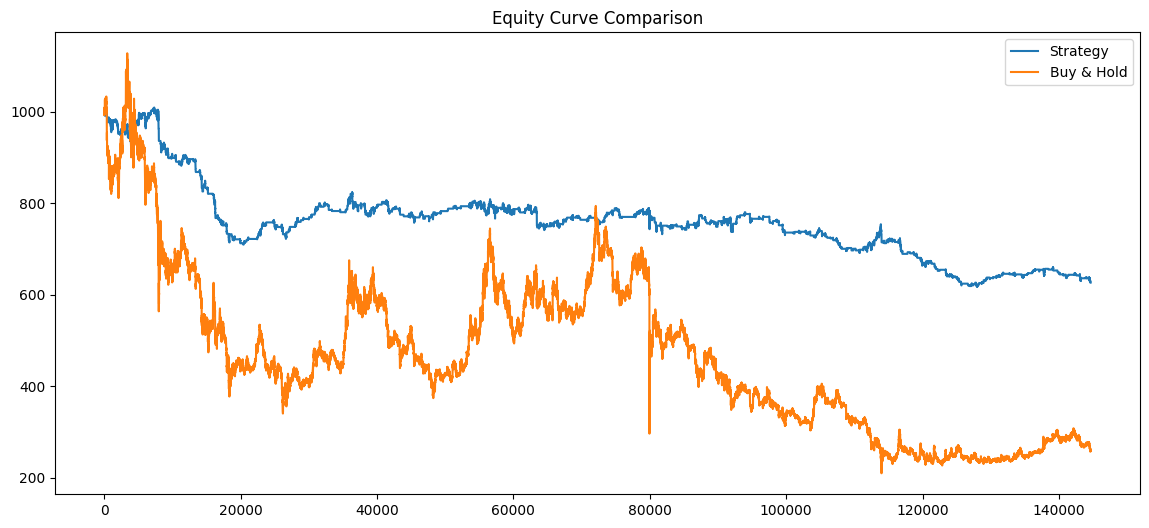

In [9]:
# ============================================================
# Equity curve comparison
# Esta visualización compara la evolución temporal del capital de la estrategia frente al benchmark Buy & Hold.
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    balances,
    label="Strategy"
)

plt.plot(
    buy_hold_equity.values,
    label="Buy & Hold"
)

plt.legend()
plt.title("Equity Curve Comparison")
plt.show()

### Interpretación de la curva de equity

La curva de equity muestra una diferencia muy clara entre la estrategia activa y Buy & Hold.

Ambos sistemas comienzan con un deterioro inicial relativamente fuerte, pero posteriormente la estrategia consigue estabilizar parcialmente el capital mientras Buy & Hold continúa degradándose de forma mucho más agresiva.

La estrategia permanece gran parte del tiempo oscilando entre aproximadamente 700 y 800 USDT antes de sufrir una caída progresiva en el último tramo del periodo.

En cambio, Buy & Hold queda completamente expuesto a la tendencia bajista general del mercado y termina cerca de mínimos históricos del intervalo.

La lectura importante no es que la estrategia gane dinero, porque no lo hace. La lectura importante es que consigue reducir bastante la destrucción de capital respecto a una exposición pasiva continua.

También se aprecia que el sistema evita movimientos explosivos tanto positivos como negativos, algo coherente con:

- Tamaños de posición limitados
- Cooldown entre operaciones
- Salidas relativamente rápidas
- Gestión dinámica mediante ATR

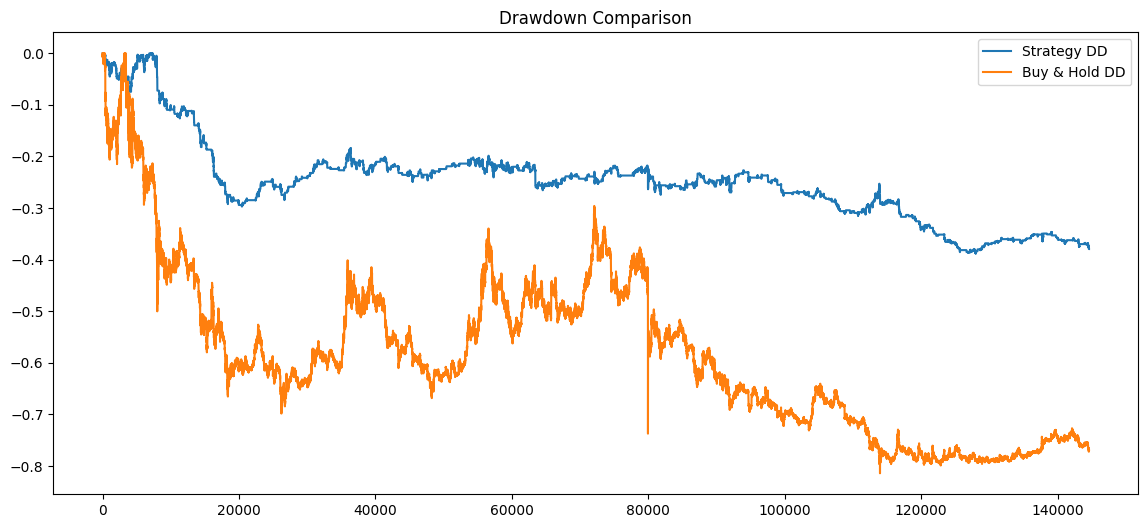

In [10]:
# ============================================================
# Drawdown comparison
# Esta visualización representa las caídas acumuladas desde máximos históricos de capital.
# ============================================================

strategy_drawdown = drawdown

buy_hold_rollmax = pd.Series(buy_hold_equity).cummax()

buy_hold_drawdown = (
    pd.Series(buy_hold_equity) - buy_hold_rollmax
) / buy_hold_rollmax

plt.figure(figsize=(14, 6))

plt.plot(strategy_drawdown, label="Strategy DD")
plt.plot(buy_hold_drawdown, label="Buy & Hold DD")

plt.legend()
plt.title("Drawdown Comparison")
plt.show()

### Interpretación del drawdown

El gráfico de drawdown confirma visualmente una de las conclusiones más importantes del notebook: la estrategia controla bastante mejor las pérdidas extremas que Buy & Hold.

Mientras que Buy & Hold alcanza drawdowns cercanos al -80%, la estrategia mantiene las caídas máximas alrededor del -40%.

Esto implica que el sistema consigue reducir significativamente la exposición neta al deterioro prolongado del mercado.

La diferencia entre ambas curvas también refleja otro comportamiento interesante:

- Buy & Hold queda totalmente atrapado en la tendencia bajista
- La estrategia consigue estabilizar parcialmente el equity durante largos periodos
- El sistema evita parte de las caídas más violentas del activo

Sin embargo, el drawdown sigue siendo elevado para un sistema de trading robusto.

Un -38% continúa siendo una pérdida considerable y deja claro que el modelo todavía no posee suficiente capacidad predictiva como para navegar mercados bajistas de forma consistente.

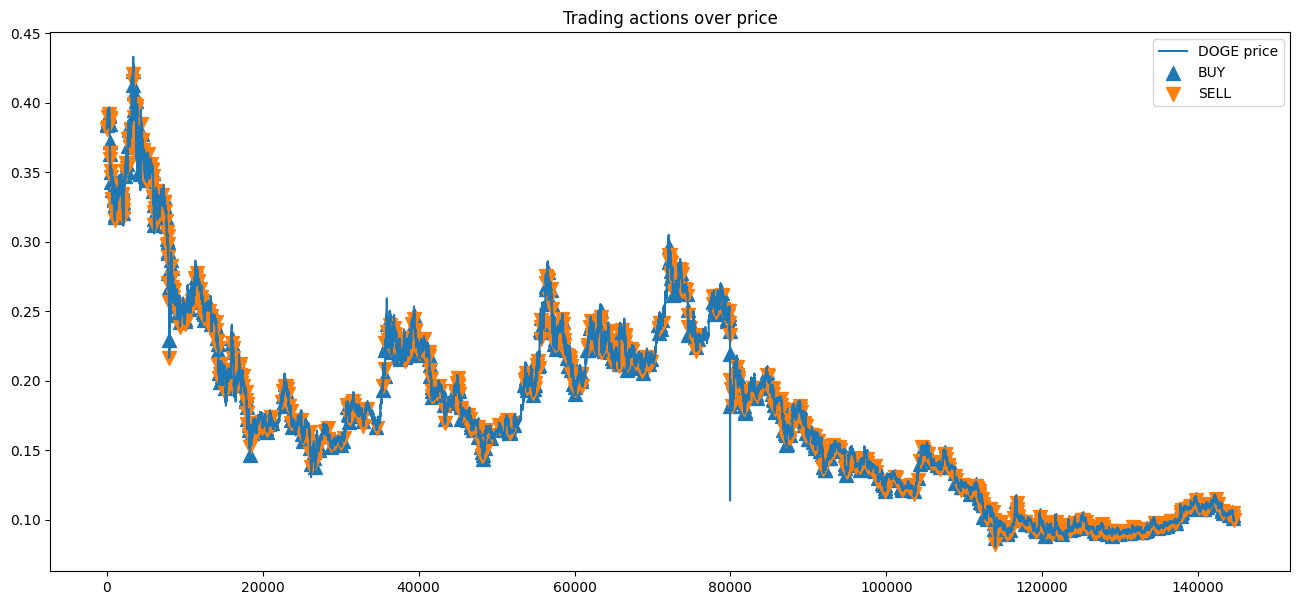

In [11]:
# ============================================================
# Trading actions over price
# Esta visualización muestra las operaciones ejecutadas directamente sobre el precio.
# ============================================================

plt.figure(figsize=(16, 7))

plt.plot(test_df["close"].values, label="DOGE price")

buy_idx = [i for i, a in enumerate(actions) if a == "BUY"]
sell_idx = [i for i, a in enumerate(actions) if a == "SELL"]

plt.scatter(
    buy_idx,
    test_df["close"].iloc[buy_idx],
    marker="^",
    s=100,
    label="BUY"
)

plt.scatter(
    sell_idx,
    test_df["close"].iloc[sell_idx],
    marker="v",
    s=100,
    label="SELL"
)

plt.legend()
plt.title("Trading actions over price")
plt.show()

### Interpretación de las operaciones sobre el precio

La visualización de operaciones muestra un comportamiento bastante coherente con la lógica implementada en el backtest.

Las entradas y salidas aparecen distribuidas a lo largo de prácticamente todo el periodo, sin concentrarse únicamente en zonas concretas del mercado. Esto sugiere que el sistema sigue reaccionando activamente incluso durante fases laterales o bajistas.

También se observan varios patrones importantes:

- Muchas operaciones duran poco tiempo
- Las señales aparecen muy próximas entre sí en determinados tramos
- El modelo cambia de sesgo con bastante frecuencia
- El sistema captura pequeños movimientos locales, pero rara vez grandes tendencias sostenidas

La estrategia parece comportarse más como un sistema defensivo de reducción parcial de exposición que como un modelo capaz de explotar grandes impulsos alcistas.

Además, visualmente no se aprecia una ventaja especialmente clara en el timing de entradas y salidas. Las operaciones siguen bastante de cerca el movimiento inmediato del precio, algo típico de modelos con señal débil en horizontes temporales muy cortos.

Este resultado refuerza una idea importante para el proyecto:

Las métricas de clasificación ligeramente superiores al azar pueden no ser suficientes para construir una estrategia realmente rentable cuando el mercado introduce ruido, volatilidad y cambios rápidos de régimen.

# Conclusión

Este notebook representa la primera validación práctica del pipeline de trading algorítmico desarrollado para el proyecto.

Mientras que el notebook de baseline evaluaba únicamente capacidad predictiva, aquí las predicciones pasan a enfrentarse por primera vez a restricciones operativas más cercanas a un entorno real:

- Gestión de capital
- Entrada y salida de mercado
- Riesgo
- Volatilidad
- Persistencia temporal de la señal
- Control de exposición

Los resultados obtenidos reflejan bastante bien la dificultad real del problema.

La estrategia termina el periodo de test con una pérdida aproximada del -37%, por lo que todavía no puede considerarse rentable. Sin embargo, el comportamiento relativo frente a Buy & Hold resulta significativamente mejor:

- La caída del capital es mucho más contenida
- El drawdown máximo se reduce prácticamente a la mitad
- El sistema evita parte de las fases de deterioro extremo del mercado
- La exposición al activo queda parcialmente controlada mediante la lógica operativa implementada

Esto sugiere que el modelo sí consigue capturar cierta información útil sobre el comportamiento del mercado, aunque dicha señal continúa siendo demasiado débil e inestable para sostener una estrategia rentable de forma consistente.

El notebook también deja una conclusión metodológica importante para el proyecto:

Una ligera mejora en métricas de clasificación no garantiza automáticamente una ventaja financiera explotable.

En entornos financieros altamente ruidosos, especialmente sobre velas de 5 minutos en criptomonedas, pequeñas ventajas estadísticas pueden desaparecer rápidamente cuando se introducen:

- Gestión monetaria
- Cambios de régimen de mercado
- Ruido intradía
- Drawdowns prolongados
- Fricción operativa
- Señales contradictorias

Aun así, el trabajo realizado valida correctamente varios componentes esenciales del sistema:

- El pipeline completo funciona extremo a extremo
- El modelo puede generar señales operativas reales
- El sistema puede simular decisiones cronológicamente
- El backtesting produce métricas financieras interpretables
- La arquitectura permite seguir iterando estrategias más avanzadas

Además, el proyecto ya incorpora elementos que van más allá de un baseline académico simple:

- Ingeniería de características financieras
- Variables estructurales de soportes y resistencias
- Comparativa entre modelos supervisados
- Gestión dinámica mediante ATR
- Control parcial de riesgo y exposición
- Evaluación frente a benchmark financiero

Las siguientes fases del proyecto deberán centrarse en mejorar la robustez del sistema mediante:

- Refinamiento de señales de entrada y salida
- Reducción de sobreoperación
- Introducción de posiciones short
- Filtros de régimen de mercado
- Costes y slippage más realistas
- Optimización de hiperparámetros
- Estrategias híbridas y aprendizaje por refuerzo

En conjunto, el notebook no demuestra la existencia de un sistema rentable listo para producción, pero sí valida algo mucho más importante desde la perspectiva del TFM: la construcción completa, coherente y reproducible de un pipeline de trading algorítmico basado en inteligencia artificial, integrando adquisición de datos, feature engineering, modelado predictivo y evaluación financiera sobre datos reales de mercado.